###  SIT720 Task 8.1 DISTINCTION TASK (Machine Learning Mini Project)
#### Name : Dineth Hasaranga  
#### Student No : 225391848  
#### Email address : s225391848@deakin.edu.au  


### Part 1: Problem Definition and Data Collection

#### Problem Definition

The aim of this project is to develop a machine learning based housing price prediction and decision support system for residential properties in Sydney. The prediction target is the sold price of a property, while the input features describe important property characteristics such as location, property type, number of bedrooms, bathrooms, car spaces and property size.

This is a supervised regression problem because the target variable, sold_price, is continuous. The model will learn patterns from previously sold properties and use those patterns to estimate the sale price of unseen properties.

The purpose of the project is not only to achieve good predictive performance. It also involves understanding the housing market, identifying the factors that influence property prices, comparing different modelling approaches and critically examining cases where predictions are inaccurate.

#### Suburb Selection

Three Sydney suburbs were selected, Burwood, Parramatta and Campbelltown

These suburbs were chosen because they represent substantially different parts of the Sydney housing market.

Burwood represents a comparatively expensive inner west market. It contains a mixture of established houses, apartments and semi detached properties. Its proximity to the Sydney CBD, major shopping facilities and strong public transport connections contribute to higher property values.

Parramatta represents a major metropolitan and commercial centre in Western Sydney. Its property market contains a broad mixture of houses, apartments, townhouses, villas and units. The suburb also has strong transport connections, employment opportunities and major commercial development.

Campbelltown represents an outer south western Sydney market. Compared with Burwood and Parramatta, properties are generally located further from the Sydney CBD and many houses have larger lands. This provides a useful contrast in location, housing characteristics and price levels.

Selecting these three suburbs allow the analysis to investigate whether the relationship between property characteristics and price changes across substantially different housing markets.

#### Data Collection

The dataset was manually constructed using publicly available sold property listings from real estate websites.

For each property, information relating to the sale and physical characteristics of the property was collected. The final dataset contains 106 sold properties across the three selected suburbs:

Suburb	Number of properties
Burwood	35
Parramatta	35
Campbelltown	36
Total	106

This satisfies the task requirement of at least 100 sold properties, with a minimum of 30 properties from each suburb.

The final dataset contains the following variables:

| Variable            | Description                                                   |
| ------------------- | ------------------------------------------------------------- |
| `suburb`            | Suburb in which the property is located                       |
| `address`           | Property address                                              |
| `postcode`          | Property postcode                                             |
| `property_type`     | Type of property, such as house, apartment, unit or townhouse |
| `bedrooms`          | Number of bedrooms                                            |
| `bathrooms`         | Number of bathrooms                                           |
| `car_spaces`        | Number of available car spaces                                |
| `property_size_sqm` | Available property size reported in square metres             |
| `sold_date`         | Date on which the property was sold                           |
| `sold_price`        | Final property sale price and prediction target               |
| `agent_name`        | Name of the listed real estate agent                          |
| `agency_name`       | Name of the real estate agency                                |
| `description`       | Text description of the property from the listing             |


The description variable was retained because it contains additional information that is not represented by the structured numerical variables. For example, descriptions may identify whether a property has been renovated, contains a swimming pool, has development potential, includes solar panels or is located close to transport and shopping facilities. This information is useful for feature engineering.

#### Property Size Variable

A single variable called property_size_sqm was used to represent the available size information for each property.

Because property websites do not report size information consistently across all property types, the value represent the available property, land, internal or total area reported in the original listing. For example, land size is commonly available for houses, while apartments instead provide internal or total property area.

This approach reduces the amount of missing information, although it introduces an important limitation because the meaning of property size may differ between houses and apartments. Therefore, property_type is considered together with property_size_sqm during the later analysis and modelling stages.

#### Data Quality and Collection Challenges

The dataset provides a useful range of properties, but several data quality issues were encountered during manual collection.

One challenge was missing information. Some listings did not provide values for every characteristic. For example, property size, car spaces or agent information was occasionally unavailable. Missing values should therefore be investigated during the data understanding stage before determining whether they require imputation or another treatment.

Another challenge was the inconsistent way property size was reported. Houses generally reported land size, while apartments and units often reported internal area, total area or the size of the broader development site. A single property_size_sqm variable was therefore retained using the available size information shown in each listing.

The collection process also required checking for duplicate and unusual sales. Duplicate listings were not included more than once. Transactions involving multiple dwellings sold together were also avoided where they were not directly comparable with an ordinary single residential property.

The property descriptions introduce another source of inconsistency. Real estate descriptions are written for marketing purposes and use subjective language such as spacious, modern or premium. Therefore, any features later extracted from this text will need to be defined systematically rather than relying directly on subjective wording.

#### Potential Bias and Limitations

The dataset is a manually collected sample rather than a complete record of all property sales in the three suburbs. As a result, sampling bias exist if the properties selected from real estate websites differ from the broader population of sold properties.

There is also variation in the distribution of property types between the suburbs. For example, one suburb may contain more apartments while another contains more detached houses. Therefore, differences in average sale price between suburbs partly reflect differences in property type rather than location alone.

The dataset contains 106 observations, which satisfies the task requirement but is still relatively small for machine learning. Complex models  therefore be more vulnerable to overfitting, particularly if many engineered variables are introduced.

Important information that influence property prices is not consistently recorded. Examples include exact distance to the CBD, distance to train stations, school catchment quality, renovation quality, property age, street characteristics and detailed zoning information.

### Part 2 - Data Understanding and Feature Engineering

#### Load and Inspect the Dataset

In [1]:
# Import Required Libraries

# 1. Data manipulation and numerical operations
import pandas as pd
import numpy as np

# 2. Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Data splitting and cross-validation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import GridSearchCV

# 4. Data preprocessing
# Apply different preprocessing steps to numerical and categorical variables
from sklearn.compose import ColumnTransformer

# Combine preprocessing and modelling steps into pipelines
from sklearn.pipeline import Pipeline

# Standardise numerical features and encode categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Handle missing values
from sklearn.impute import SimpleImputer

# 5. Regression models
# Linear Regression baseline model
from sklearn.linear_model import LinearRegression

# Random Forest regression model
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting regression model
from sklearn.ensemble import GradientBoostingRegressor

# 6. Model evaluation metrics
# Metrics used to evaluate regression performance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 7. Model saving and deployment
# Save and load the final trained machine learning model
import joblib

In [2]:
# Load the property dataset

property_df = pd.read_excel("Property_dataset.xlsx")

# Display the first five rows
property_df.head()

,suburb,address,postcode,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,sold_date,sold_price,agent_name,agency_name,description
0,Burwood,"73 Liverpool Road, Burwood NSW 2134",2134,House,3,1,4.0,613.3,2026-09-04,1700000,Marco Erricheillo,Rich & Oliva,Single level three bedroom house on a 613.3 sq...
1,Burwood,"38/67 Shaftesbury Road, Burwood NSW 2134",2134,Apartment,2,2,1.0,101.0,2026-09-04,890000,Aaron Chen,Ray White,North facing ground floor two bedroom apartmen...
2,Burwood,"G02/15-19 Clarence Street, Burwood NSW 2134",2134,Apartment,2,2,2.0,140.0,2026-09-01,1360000,Mathew Everingham,Richard Mathews,North east facing two bedroom apartment with a...
3,Burwood,"1/27-27A Conder Street, Burwood NSW 2134",2134,Duplex/semi-detached,3,2,3.0,306.5,2026-08-29,2330000,Marco Erricheillo,Rich & Oliva,Full brick three bedroom duplex with built in ...
4,Burwood,"3/6-8 Belmore Street, Burwood NSW 2134",2134,Apartment,2,1,1.0,83.6,2026-08-13,725000,Michael Ke Ma,Belle Property,Renovated first floor two bedroom apartment in...


In [3]:
# Check the number of rows and columns
property_df.shape

(106, 13)

In [4]:
# Display the column names
property_df.columns

Index(['suburb', 'address', 'postcode', 'property_type', 'bedrooms',
       'bathrooms', 'car_spaces', 'property_size_sqm', 'sold_date',
       'sold_price', 'agent_name', 'agency_name', 'description'],
      dtype='object')

In [5]:
# Check the data types and non-null values
property_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   suburb             106 non-null    object        
 1   address            106 non-null    object        
 2   postcode           106 non-null    int64         
 3   property_type      106 non-null    object        
 4   bedrooms           106 non-null    int64         
 5   bathrooms          106 non-null    int64         
 6   car_spaces         101 non-null    float64       
 7   property_size_sqm  105 non-null    float64       
 8   sold_date          106 non-null    datetime64[ns]
 9   sold_price         106 non-null    int64         
 10  agent_name         104 non-null    object        
 11  agency_name        106 non-null    object        
 12  description        105 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usag

#### Check missing values

In [6]:
# Check the number of missing values in each column
property_df.isnull().sum()

suburb               0
address              0
postcode             0
property_type        0
bedrooms             0
bathrooms            0
car_spaces           5
property_size_sqm    1
sold_date            0
sold_price           0
agent_name           2
agency_name          0
description          1
dtype: int64

The dataset contains 106 property records and 13 variables. Most fields are complete, with only a small number of missing values. Five observations are missing car_spaces, one is missing property_size_sqm, two are missing agent_name, and one is missing a property description. Since the missingness is limited, these values can be handled later based on the role of each variable in the modelling process.

#### Check duplicate rows

In [7]:
# Check for completely duplicated rows
property_df.duplicated().sum()

np.int64(0)

#### Check duplicate property addresses

In [8]:
# Check whether the same property address appears more than once
property_df["address"].duplicated().sum()

np.int64(0)

#### Check suburb distribution

In [9]:
# Count the number of properties collected from each suburb
property_df["suburb"].value_counts()

suburb
Campbelltown    36
Burwood         35
Parramatta      35
Name: count, dtype: int64

#### Check property type distribution

In [10]:
# Examine the distribution of property types
property_df["property_type"].value_counts()

property_type
House                   75
Apartment               17
Unit                     7
Duplex/semi-detached     3
Townhouse                3
Villa                    1
Name: count, dtype: int64

No completely duplicated rows or duplicated property addresses were found, which confirms that each property appears only once in the dataset. The suburb distribution is also well balanced, with 36 properties from Campbelltown and 35 each from Burwood and Parramatta. Houses make up the largest group with 75 observations, followed by apartments and units. The smaller number of townhouses, duplexes and villas should be considered when comparing property types because these categories have much less representation.

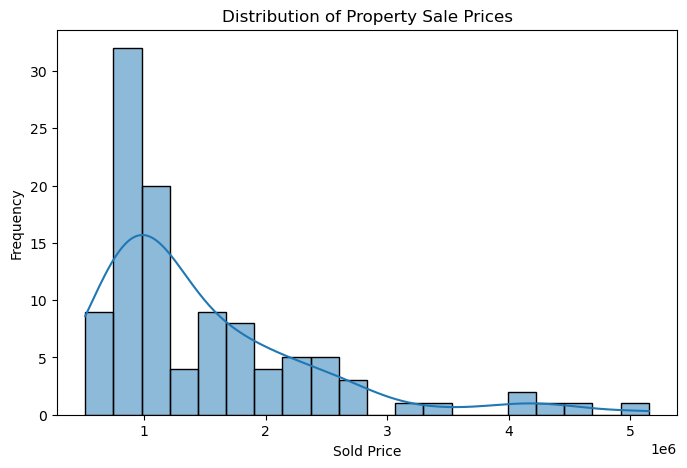

In [11]:
# Plot the distribution of sold prices

plt.figure(figsize=(8, 5))

sns.histplot(
    data=property_df,
    x="sold_price",
    bins=20,
    kde=True
)

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sold Price")
plt.ylabel("Frequency")

plt.show()

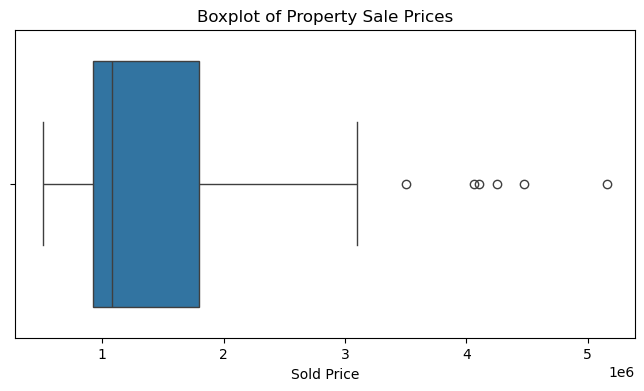

In [12]:
# Plot sold prices to identify spread and possible outliers

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=property_df,
    x="sold_price"
)

plt.title("Boxplot of Property Sale Prices")
plt.xlabel("Sold Price")

plt.show()

The distribution of property sale prices is positively skewed. Most properties were sold within the lower to middle price range, while a smaller number of properties achieved substantially higher sale prices. The boxplot also identifies several high price observations as potential outliers. These values should not be removed automatically because they represent genuine premium properties. 

#### Summary Statistics

In [13]:
# Display summary statistics for sold prices
property_df["sold_price"].describe()

count    1.060000e+02
mean     1.488651e+06
std      9.082368e+05
min      5.140000e+05
25%      9.212500e+05
50%      1.084000e+06
75%      1.800000e+06
max      5.155000e+06
Name: sold_price, dtype: float64

The average sale price is approximately 1.49 million dollars, while the median sale price is about 1.08 million dollars. The mean is noticeably higher than the median, which supports the earlier observation that the price distribution is positively skewed. The middle 50% of properties were sold between approximately 921,250 dollars and 1.80 million dollars, while the full price range extends from 514,000 dollars to 5.16 million dollars. The relatively large standard deviation of about $908,000 also indicates substantial variation in property prices across the dataset.

#### Average and median sale price by suburb

In [14]:
# Calculate summary statistics for sold price by suburb
suburb_price_summary = property_df.groupby("suburb")["sold_price"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
)

suburb_price_summary

,count,mean,median,minimum,maximum
suburb,,,,,
Burwood,35,2.147211e+06,2185000.0,725000,5155000
Campbelltown,36,9.911126e+05,972750.0,584000,1310000
Parramatta,35,1.341846e+06,1480000.0,514000,2175000


#### Boxplot of sale prices by suburb

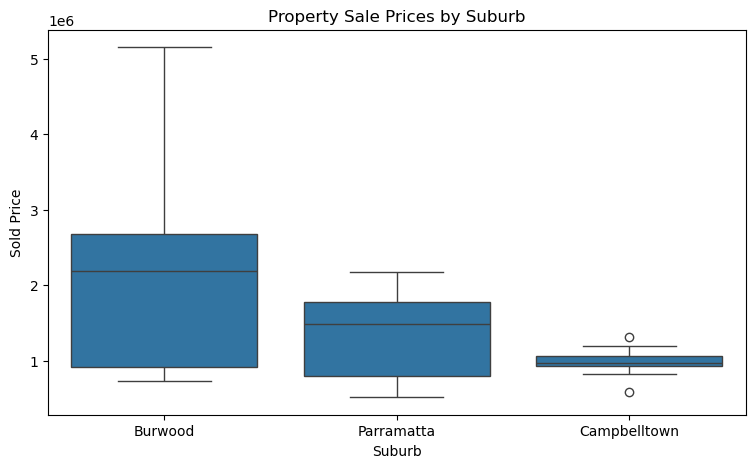

In [15]:
# Compare sold price distributions across suburbs
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=property_df,
    x="suburb",
    y="sold_price"
)

plt.title("Property Sale Prices by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sold Price")

plt.show()

The comparison shows a clear difference in property prices across the three suburbs. Burwood has the highest median sale price at about 2.19 million dollars, followed by Parramatta at around 1.48 million dollars, while Campbelltown has the lowest median at approximately 973,000 dollars. Burwood also shows the greatest variation in prices, with some properties selling for more than 5 million dollars, while Campbelltown has a much narrower price range. These results indicate that suburb location has a strong influence on property value, supporting the decision to select three suburbs that represent different Sydney housing markets.

#### Examine Property Price Trends Over Time.

In [16]:
# Create a month variable from the sold date
property_df["sold_month"] = property_df["sold_date"].dt.to_period("M").astype(str)

In [17]:
# Calculate monthly median sale price for each suburb
monthly_suburb_prices = (
    property_df
    .groupby(["sold_month", "suburb"])["sold_price"]
    .median()
    .reset_index()
)

monthly_suburb_prices.head()

,sold_month,suburb,sold_price
0,2024-07,Parramatta,821000.0
1,2024-08,Parramatta,2175000.0
2,2024-09,Parramatta,2005000.0
3,2024-12,Parramatta,1287500.0
4,2025-01,Parramatta,1850000.0


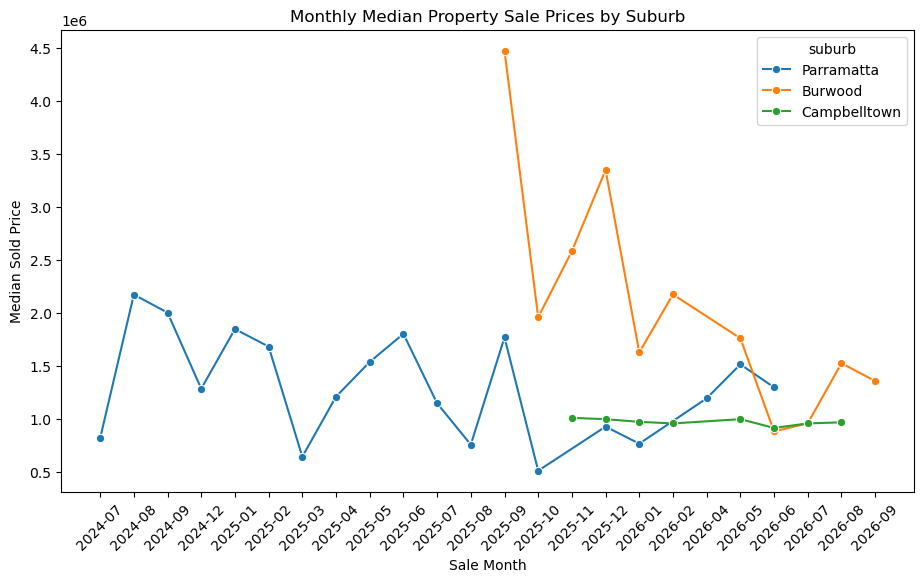

In [18]:
# Plot monthly median sale price trends by suburb

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=monthly_suburb_prices,
    x="sold_month",
    y="sold_price",
    hue="suburb",
    marker="o"
)

plt.title("Monthly Median Property Sale Prices by Suburb")
plt.xlabel("Sale Month")
plt.ylabel("Median Sold Price")
plt.xticks(rotation=45)

plt.show()

This graph shows that property prices changed differently across the three suburbs over time. Burwood consistently recorded the highest monthly median prices. Its values fluctuated considerably because some months contained very expensive properties. Parramatta remained in the middle price range, with noticeable month to month variation, while Campbelltown showed the most stable pattern, with monthly median prices staying close to around $1 million. The graph shows that suburb level market differences are stronger than any clear overall upward or downward time trend in this dataset. The monthly results should be interpreted carefully because some months contain only a small number of sales, which can cause the median to change sharply.

#### Examine Relationships Between Property Characteristics and Sale Price.

In [19]:
# Check correlations between numerical property features and sold price
numeric_features = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_sqm",
    "sold_price"
]

property_df[numeric_features].corr()

,bedrooms,bathrooms,car_spaces,property_size_sqm,sold_price
bedrooms,1.000000,0.444147,0.430405,0.381601,0.621976
bathrooms,0.444147,1.000000,0.220084,-0.026640,0.387600
car_spaces,0.430405,0.220084,1.000000,0.213324,0.375046
property_size_sqm,0.381601,-0.026640,0.213324,1.000000,0.191869
sold_price,0.621976,0.387600,0.375046,0.191869,1.000000


The correlation analysis shows that bedrooms have the strongest numerical relationship with sale price, with a correlation of approximately 0.62. Bathrooms and car spaces have weaker positive correlations of about 0.39 and 0.38, while property size has a relatively weak correlation of around 0.19. The property size scatter plot also shows clear suburb based clustering. Burwood properties generally achieve higher prices than similarly sized properties in Parramatta or Campbelltown. This shows that property value is influenced by a combination of physical characteristics and location, rather than size alone. The weak relationship for property_size_sqm is partly explained by differences in how size is reported across different property types.

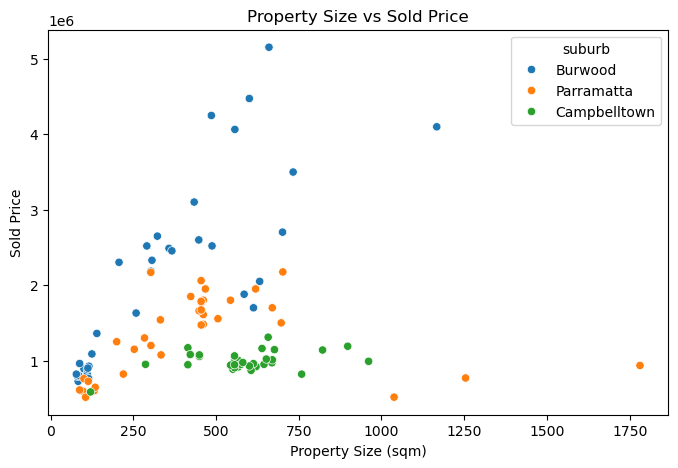

In [20]:
# Relationship between property size and sold price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=property_df,
    x="property_size_sqm",
    y="sold_price",
    hue="suburb"
)

plt.title("Property Size vs Sold Price")
plt.xlabel("Property Size (sqm)")
plt.ylabel("Sold Price")

plt.show()

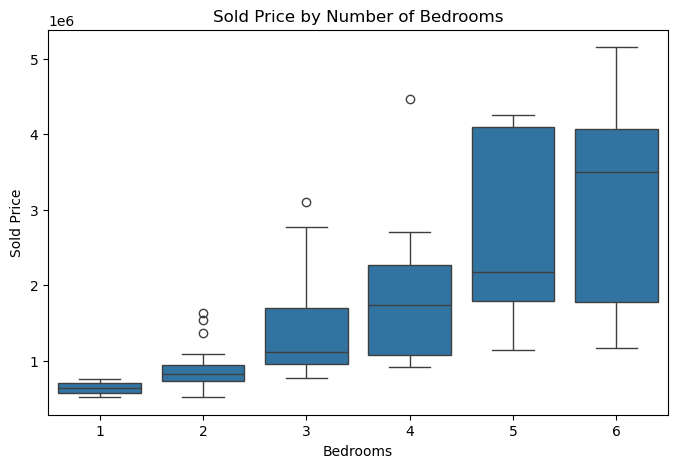

In [21]:
# Relationship between bedrooms and sold price

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=property_df,
    x="bedrooms",
    y="sold_price"
)

plt.title("Sold Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Sold Price")

plt.show()

The boxplot shows a clear positive relationship between the number of bedrooms and property sale price. Properties with fewer bedrooms are generally concentrated in the lower price range, while properties with five or six bedrooms tend to have much higher median sale prices. The spread of prices also becomes wider as the number of bedrooms increases. This proves that larger properties vary more in value depending on factors such as suburb, property type and overall quality. This supports the correlation result, where bedrooms showed the strongest numerical relationship with sold price.

#### Identify Unusual Observations and Potential Outliers.

In [22]:
# Calculate Q1, Q3 and IQR for sold price

Q1 = property_df["sold_price"].quantile(0.25)
Q3 = property_df["sold_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -396875.0
Upper bound: 3118125.0


In [23]:
# Identify potential sold price outliers

price_outliers = property_df[
    (property_df["sold_price"] < lower_bound) |
    (property_df["sold_price"] > upper_bound)
]

price_outliers[
    [
        "suburb",
        "address",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "sold_price"
    ]
].sort_values("sold_price", ascending=False)

,suburb,address,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,sold_price
27,Burwood,"2A Woodside Avenue, Burwood NSW 2134",House,6,4,2.0,660.1,5155000
34,Burwood,"4A Eurella Street, Burwood NSW 2134",House,4,2,2.0,600.7,4475000
28,Burwood,"59 Stanley Street, Burwood NSW 2134",House,5,3,3.0,486.0,4250000
18,Burwood,"11 Seale Street, Burwood NSW 2134",House,5,2,4.0,1167.0,4100000
22,Burwood,"7 Nicholson Street, Burwood NSW 2134",House,6,2,2.0,557.0,4065000
26,Burwood,"41 Weldon Street, Burwood NSW 2134",House,6,2,2.0,733.0,3500000


In [24]:
# Count potential sold price outliers
price_outliers.shape[0]

6

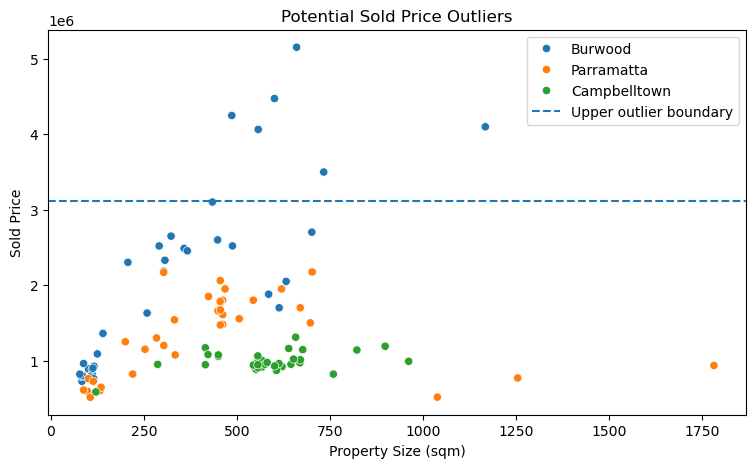

In [25]:
# Highlight potential sold price outliers

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=property_df,
    x="property_size_sqm",
    y="sold_price",
    hue="suburb"
)

plt.axhline(
    upper_bound,
    linestyle="--",
    label="Upper outlier boundary"
)

plt.title("Potential Sold Price Outliers")
plt.xlabel("Property Size (sqm)")
plt.ylabel("Sold Price")

plt.legend()
plt.show()

The IQR method identified six potential high price outliers, all located in Burwood. These properties sold for more than approximately 3.12 million dollars, with the highest sale reaching about 5.16 million dollars. Although they are statistically unusual, they appear to be genuine premium properties rather than incorrect observations. Most are large detached houses with four to six bedrooms, multiple bathrooms and relatively large property sizes. Therefore, these observations were retained because removing them would reduce the dataset’s ability to represent the upper end of the Burwood housing market.

#### Initial Three Most Influential Variables

Before developing the regression models, I expect suburb, number of bedrooms, and property type to have the strongest influence on sale price.

Suburb is expected to be one of the most important variables because the exploratory analysis showed clear differences in typical property prices between Burwood, Parramatta and Campbelltown. Burwood had the highest median sale price, followed by Parramatta, while Campbelltown had the lowest. This suggests that location captures important market factors such as accessibility, demand, nearby services and broader neighbourhood characteristics.

Bedrooms is also expected to have a strong influence because it showed the strongest numerical correlation with sold_price, at approximately 0.62. The bedroom boxplot also showed that properties with more bedrooms generally had higher median sale prices, although the price range became wider for larger properties.

Property type is expected to be important because houses, apartments, units, townhouses and duplexes represent different forms of housing with different size, land and market characteristics. The dataset also contains a large number of houses compared with other property types, so differences between these categories explain a substantial part of the variation in sale prices.


#### Feature Engineering.

#### Create Date Features

In [26]:
# Create year and month features from the sold date

property_df["sale_year"] = property_df["sold_date"].dt.year
property_df["sale_month_num"] = property_df["sold_date"].dt.month

#### Create Text Based Property Features

In [27]:
# Convert descriptions to lowercase text
# Missing descriptions are replaced with an empty string

description_text = property_df["description"].fillna("").str.lower()

In [28]:
# Create binary features from property descriptions

property_df["has_pool"] = description_text.str.contains(
    r"\bpool\b|swimming pool|in ground pool|inground pool",
    regex=True
).astype(int)

property_df["renovated"] = description_text.str.contains(
    r"\brenovated\b|recently renovated|fully renovated|newly renovated|updated",
    regex=True
).astype(int)

property_df["has_solar"] = description_text.str.contains(
    r"solar panel|solar panels|solar system|solar power",
    regex=True
).astype(int)

property_df["development_potential"] = description_text.str.contains(
    r"development potential|redevelopment potential|granny flat potential|stca",
    regex=True
).astype(int)

In [29]:
# Create structured engineered features

# Total number of bedrooms and bathrooms
property_df["total_rooms"] = (
    property_df["bedrooms"] +
    property_df["bathrooms"]
)

# Indicate whether the property has at least one parking space
property_df["has_parking"] = (
    property_df["car_spaces"].fillna(0) > 0
).astype(int)


In [30]:
# Create time related features from the sold date

property_df["sale_year"] = property_df["sold_date"].dt.year
property_df["sale_quarter"] = property_df["sold_date"].dt.quarter

In [31]:
# Display selected original and engineered features

property_df[
    [
        "address",
        "suburb",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "sale_year",
        "sale_quarter",
        "total_rooms",
        "has_parking",
        "has_pool",
        "renovated",
        "has_solar",
        "development_potential"
    ]
].head(10)

,address,suburb,bedrooms,bathrooms,car_spaces,property_size_sqm,sale_year,sale_quarter,total_rooms,has_parking,has_pool,renovated,has_solar,development_potential
0,"73 Liverpool Road, Burwood NSW 2134",Burwood,3,1,4.0,613.3,2026,3,4,1,0,0,0,1
1,"38/67 Shaftesbury Road, Burwood NSW 2134",Burwood,2,2,1.0,101.0,2026,3,4,1,0,0,0,0
2,"G02/15-19 Clarence Street, Burwood NSW 2134",Burwood,2,2,2.0,140.0,2026,3,4,1,0,0,0,0
3,"1/27-27A Conder Street, Burwood NSW 2134",Burwood,3,2,3.0,306.5,2026,3,5,1,0,0,0,0
4,"3/6-8 Belmore Street, Burwood NSW 2134",Burwood,2,1,1.0,83.6,2026,3,3,1,0,1,0,0
5,"100 Wentworth Road, Burwood NSW 2134",Burwood,4,2,2.0,291.0,2026,3,6,1,0,1,0,1
6,"301/24A-26 Gordon Street, Burwood NSW 2134",Burwood,2,2,2.0,88.0,2026,3,4,1,0,0,0,0
7,"32/1-9 Mt Pleasant Avenue, Burwood NSW 2134",Burwood,2,2,2.0,82.0,2026,3,4,1,0,0,0,0
8,"9/41-43 Railway Crescent, Burwood NSW 2134",Burwood,2,2,1.0,111.0,2026,2,4,1,0,0,0,0
9,"11/4 Belmore Street, Burwood NSW 2134",Burwood,2,1,1.0,85.0,2026,2,3,1,0,0,0,0


The engineered features were selected to capture additional information about property capacity, parking, time of sale and important characteristics contained in the property descriptions. total_rooms combines bedrooms and bathrooms into a simple summary of the property's main accommodation related spaces., while has_parking, has_pool, renovated, has_solar and development_potential represent useful property attributes that may influence sale price. sale_year and sale_quarter were also included to capture possible changes in the housing market over time.

#### Check the Engineered Features

In [32]:
# Count the number of properties with each binary engineered feature

engineered_feature_counts = property_df[
    [
        "has_parking",
        "has_pool",
        "renovated",
        "has_solar",
        "development_potential"
    ]
].sum()

engineered_feature_counts

has_parking              101
has_pool                   6
renovated                 32
has_solar                  5
development_potential     11
dtype: int64

In [33]:
# Check the distribution of total rooms

property_df["total_rooms"].value_counts().sort_index()

# Create a table showing the distribution of total room capacity

total_rooms_distribution = (
    property_df["total_rooms"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename the columns
total_rooms_distribution.columns = [
    "Total Room Capacity",
    "Number of Properties"
]

total_rooms_distribution

,Total Room Capacity,Number of Properties
0,2,2
1,3,12
2,4,45
3,5,18
4,6,15
5,7,6
6,8,7
7,10,1


In [34]:
# Create a table showing the number of properties by sale year

sale_year_distribution = (
    property_df["sale_year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename the columns
sale_year_distribution.columns = [
    "Sale Year",
    "Number of Properties"
]

sale_year_distribution

,Sale Year,Number of Properties
0,2024,6
1,2025,46
2,2026,54


In [35]:
# Create a table showing the number of properties by sale quarter

sale_quarter_distribution = (
    property_df["sale_quarter"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename the columns
sale_quarter_distribution.columns = [
    "Sale Quarter",
    "Number of Properties"
]

sale_quarter_distribution

,Sale Quarter,Number of Properties
0,1,18
1,2,36
2,3,23
3,4,29


#### Check Relationships With Sold Price

In [36]:
# Calculate the correlation between total rooms and sold price

total_rooms_correlation = property_df["total_rooms"].corr(
    property_df["sold_price"]
)

print("Correlation between Total Rooms and Sold Price:",
      round(total_rooms_correlation, 3))

Correlation between Total Rooms and Sold Price: 0.619


In [37]:
# Compare average sold price based on engineered binary features

binary_features = [
    "has_parking",
    "has_pool",
    "renovated",
    "has_solar",
    "development_potential"
]

for feature in binary_features:
    print(f"\nAverage sold price by {feature}:")
    print(
        property_df.groupby(feature)["sold_price"].mean()
    )


Average sold price by has_parking:
has_parking
0    1.276200e+06
1    1.499169e+06
Name: sold_price, dtype: float64

Average sold price by has_pool:
has_pool
0    1.472060e+06
1    1.765176e+06
Name: sold_price, dtype: float64

Average sold price by renovated:
renovated
0    1.438682e+06
1    1.604205e+06
Name: sold_price, dtype: float64

Average sold price by has_solar:
has_solar
0    1.476357e+06
1    1.737000e+06
Name: sold_price, dtype: float64

Average sold price by development_potential:
development_potential
0    1.361958e+06
1    2.582818e+06
Name: sold_price, dtype: float64


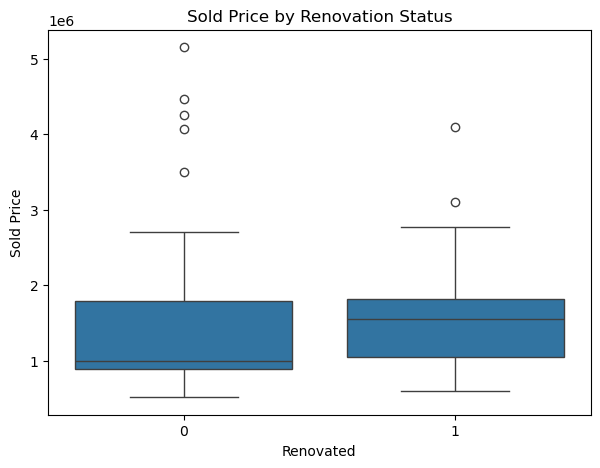

In [38]:
# Compare sold prices for renovated and non-renovated properties

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=property_df,
    x="renovated",
    y="sold_price"
)

plt.title("Sold Price by Renovation Status")
plt.xlabel("Renovated")
plt.ylabel("Sold Price")

plt.show()

The exploratory analysis generally supported the initial expectation that suburb, bedrooms and property type would be important predictors of sale price. Suburb showed clear differences in typical prices, with Burwood substantially more expensive than Parramatta and Campbelltown. Bedrooms had a moderately strong positive relationship with sale price, with a correlation of approximately 0.62. The engineered total_rooms feature showed a similar correlation of approximately 0.62, suggesting that overall accommodation capacity is useful. Additional features derived from the property descriptions, including renovation status, swimming pools, solar features and development potential, showed differences in average sale prices. Some of these features occur in only a small number of properties and is associated with suburb or property type. 

### Part 3: Model Development and Evaluation

#### Linear Regression

Linear Regression will be used as a simple and interpretable baseline model. It estimates the relationship between the input features and sold_price using a linear equation.

Why it is suitable:  

 - Easy to interpret  
 - Provides a useful baseline  
 - Works well when relationships are approximately linear  
 - Helps to show whether more complex models provide meaningful improvement  

Limitation:

 - May underfit if relationships between features and property prices are nonlinear

#### Random Forest Regressor

Random Forest is an ensemble tree based model that combines predictions from many decision trees.

Why it is suitable:  

 - Can capture nonlinear relationships  
 - Handles interactions between variables automatically  
 - Less sensitive to outliers than Linear Regression  
 - Able to model complex relationships between suburb, property type, bedrooms and price  

Limitation:

 - Less interpretable than Linear Regression  
 - Can overfit if the model becomes too complex  
 - Perform less consistently with a relatively small dataset  

#### Gradient Boosting Regressor

Gradient Boosting builds a sequence of smaller decision trees, where each new tree attempts to correct errors made by the previous trees.

Why it is suitable:

 - Strong performance on structured tabular data  
 - Captures nonlinear patterns and interactions  
 - Performs well when relationships are complex  

Limitation:

 - Sensitive to hyperparameter choices  
 - Can overfit if too many trees or excessive model complexity are used  
 - Requires more careful tuning than Linear Regression  

Before model training, I expect the Gradient Boosting Regressor to achieve the strongest predictive performance. The exploratory analysis showed that housing prices are influenced by nonlinear relationships and interactions between variables such as suburb, bedrooms, property type and property size. Gradient boosting can model these complex relationships more effectively than Linear Regression while progressively correcting prediction errors.

#### Prepare the Modelling Dataset

In [39]:
# Define the predictor variables

feature_columns = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_sqm",
    "sale_year",
    "sale_quarter",
    "has_pool",
    "renovated",
    "has_solar",
    "development_potential"
]

X = property_df[feature_columns]

# Define the prediction target
y = property_df["sold_price"]

In [40]:
# Check the predictor and target dimensions

print("Predictor data shape:", X.shape)
print("Target data shape:", y.shape)

Predictor data shape: (106, 12)
Target data shape: (106,)


#### Create a Held Out Test Set

In [41]:
# Split the data into training and held-out test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training properties:", X_train.shape[0])
print("Test properties:", X_test.shape[0])

Training properties: 84
Test properties: 22


#### Separate Numerical and Categorical Features

In [42]:
# Define numerical features

numerical_features = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_sqm",
    "sale_year",
    "sale_quarter",
    "has_pool",
    "renovated",
    "has_solar",
    "development_potential"
]

# Define categorical features

categorical_features = [
    "suburb",
    "property_type"
]

#### Preprocessing

In [43]:
# Create preprocessing steps for numerical variables

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [44]:
# Create preprocessing steps for categorical variables

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [45]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Numerical missing values were handled using median imputation because the median is less affected by extreme property values than the mean. Numerical variables were standardised so that variables measured on different scales could be treated consistently, particularly by Linear Regression. Categorical variables such as suburb and property type were transformed using one hot encoding. All preprocessing was placed inside the modelling pipeline so that imputation, scaling and encoding were learned only from the training data during cross validation, reducing the risk of data leakage.

#### Linear Regression Baseline

In [46]:
# Create the Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [47]:
# Create 5-fold cross-validation

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [48]:
# Define the evaluation metrics

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

In [49]:
# Evaluate Linear Regression using 5-fold cross-validation

linear_cv_results = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

In [50]:
# Calculate average Linear Regression performance

linear_mae = -linear_cv_results["test_MAE"].mean()
linear_rmse = np.sqrt( -linear_cv_results["test_MSE"].mean())
linear_r2 = linear_cv_results["test_R2"].mean()

print("Linear Regression Cross-Validation Results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 4))

Linear Regression Cross-Validation Results
MAE: 364171.77
RMSE: 488772.55
R²: 0.6991


In [51]:
# Calculate average training performance

linear_train_mae = -linear_cv_results["train_MAE"].mean()
linear_train_rmse = np.sqrt(-linear_cv_results["train_MSE"].mean())
linear_train_r2 = linear_cv_results["train_R2"].mean()

print("Linear Regression Training Results")
print("MAE:", round(linear_train_mae, 2))
print("RMSE:", round(linear_train_rmse, 2))
print("R²:", round(linear_train_r2, 4))

Linear Regression Training Results
MAE: 230767.56
RMSE: 311175.29
R²: 0.8856


Linear Regression achieved a cross-validation R² of approximately 0.70, meaning that the model explained about 70% of the variation in property sale prices across the validation folds. The average MAE was around 364,000 dollars, while the RMSE was approximately 489,000 dollars, showing that some larger prediction errors were present. The training R² was much higher at approximately 0.89, with lower training errors. This gap between training and validation performance shows that the model fit the training data more closely than it generalises to unseen data. The validation performance is still reasonably strong for a baseline model.

#### Random Forest Regressor

In [52]:
# Create the Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

In [53]:
# Evaluate Random Forest using 5-fold cross-validation

rf_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

In [54]:
# Calculate average Random Forest validation performance

rf_mae = -rf_cv_results["test_MAE"].mean()

rf_rmse = np.sqrt(-rf_cv_results["test_MSE"].mean())

rf_r2 = rf_cv_results["test_R2"].mean()

print("Random Forest Cross-Validation Results")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 4))

Random Forest Cross-Validation Results
MAE: 251257.12
RMSE: 442312.99
R²: 0.7654


In [55]:
# Calculate average Random Forest training performance

rf_train_mae = -rf_cv_results["train_MAE"].mean()

rf_train_rmse = np.sqrt(-rf_cv_results["train_MSE"].mean())

rf_train_r2 = rf_cv_results["train_R2"].mean()

print("Random Forest Training Results")
print("MAE:", round(rf_train_mae, 2))
print("RMSE:", round(rf_train_rmse, 2))
print("R²:", round(rf_train_r2, 4))

Random Forest Training Results
MAE: 102360.38
RMSE: 183372.7
R²: 0.9604


The Random Forest Regressor achieved a cross-validation R² of approximately 0.77, which is higher than the Linear Regression result of about 0.70. Its average MAE also decreased to around 251,000 dollars, indicating better predictive accuracy on unseen validation folds. The training R² was very high at approximately 0.96, with much lower training errors. This large gap between training and validation performance shows that Random Forest is fitting the training data very closely and shows some overfitting. It's validation results are stronger than those of Linear Regression.

#### Gradient Boosting Regressor

In [56]:
# Create the Gradient Boosting pipeline

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [57]:
# Evaluate Gradient Boosting using 5-fold cross-validation

gb_cv_results = cross_validate(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

In [58]:
# Calculate average Gradient Boosting validation performance

gb_mae = -gb_cv_results["test_MAE"].mean()

gb_rmse = np.sqrt(-gb_cv_results["test_MSE"].mean())

gb_r2 = gb_cv_results["test_R2"].mean()

print("Gradient Boosting Cross-Validation Results")
print("MAE:", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²:", round(gb_r2, 4))

Gradient Boosting Cross-Validation Results
MAE: 257211.4
RMSE: 449561.01
R²: 0.7579


In [59]:
# Calculate average Gradient Boosting training performance

gb_train_mae = -gb_cv_results["train_MAE"].mean()

gb_train_rmse = np.sqrt(-gb_cv_results["train_MSE"].mean())

gb_train_r2 = gb_cv_results["train_R2"].mean()

print("Gradient Boosting Training Results")
print("MAE:", round(gb_train_mae, 2))
print("RMSE:", round(gb_train_rmse, 2))
print("R²:", round(gb_train_r2, 4))

Gradient Boosting Training Results
MAE: 30572.41
RMSE: 40700.52
R²: 0.9981


The Gradient Boosting Regressor achieved a cross-validation R² of approximately 0.76, with an average MAE of about 257,000 dollars and RMSE of about 450,000 dollars. Its validation performance was strong, but slightly below the Random Forest model. The training R² was extremely high at approximately 0.998, with very low training errors, indicating that the model fitted the training data almost perfectly. This large difference between training and validation performance shows clear overfitting. Although Gradient Boosting captured complex relationships in the training data, its additional complexity did not improve generalisation compared with Random Forest.

In [60]:
# Compare cross-validation performance of all three models

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "CV MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "CV RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "CV R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ],
    "Training R2": [
        linear_train_r2,
        rf_train_r2,
        gb_train_r2
    ]
})

model_comparison.round(3)

,Model,CV MAE,CV RMSE,CV R2,Training R2
0,Linear Regression,364171.766,488772.554,0.699,0.886
1,Random Forest,251257.123,442312.992,0.765,0.960
2,Gradient Boosting,257211.403,449561.008,0.758,0.998


The Random Forest Regressor produced the strongest cross-validation performance, with the highest validation R² and the lowest MAE and RMSE among the three models. Linear Regression performed reasonably well as a baseline but showed weaker predictive accuracy. Gradient Boosting achieved similar validation performance to Random Forest, but its training R² was almost perfect, indicating much stronger overfitting. Based on the balance between predictive performance and generalisation, Random Forest was selected as the preferred model.

#### Hyperparameter Tuning for Random Forest

In [61]:
# Define a compact hyperparameter grid for Random Forest

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 1.0]
}

These parameters control:

n_estimators → number of trees  
max_depth → maximum depth of each tree  
min_samples_split → minimum observations needed to split a node  
min_samples_leaf → minimum observations allowed in a leaf  
max_features → number of predictors considered when creating each split  

Increasing restrictions such as max_depth, min_samples_split, and min_samples_leaf can help reduce the overfitting that was observed in the original Random Forest.

In [62]:
# Tune the Random Forest model using 5-fold cross-validation

rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=kfold,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 8], 'model__max_features': ['sqrt', 1.0], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [63]:
# Display the best Random Forest hyperparameters

print("Best Random Forest Parameters:")

for parameter, value in rf_grid_search.best_params_.items():
    print(parameter, ":", value)

Best Random Forest Parameters:
model__max_depth : None
model__max_features : sqrt
model__min_samples_leaf : 1
model__min_samples_split : 2
model__n_estimators : 200


In [64]:
# Display the best cross-validation MAE

best_rf_mae = -rf_grid_search.best_score_

print("Best Random Forest CV MAE:", round(best_rf_mae, 2))

Best Random Forest CV MAE: 238352.64


In [65]:
# Retrieve the best tuned Random Forest model

tuned_rf_model = rf_grid_search.best_estimator_

In [66]:
# Evaluate the tuned Random Forest using 5-fold cross-validation

tuned_rf_cv_results = cross_validate(
    tuned_rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

In [67]:
# Calculate average tuned Random Forest validation performance

tuned_rf_mae = -tuned_rf_cv_results["test_MAE"].mean()

tuned_rf_rmse = np.sqrt(-tuned_rf_cv_results["test_MSE"].mean())

tuned_rf_r2 = tuned_rf_cv_results["test_R2"].mean()

print("Tuned Random Forest Cross-Validation Results")
print("MAE:", round(tuned_rf_mae, 2))
print("RMSE:", round(tuned_rf_rmse, 2))
print("R²:", round(tuned_rf_r2, 4))

Tuned Random Forest Cross-Validation Results
MAE: 238352.64
RMSE: 413195.35
R²: 0.8062


In [68]:
# Calculate average tuned Random Forest training performance

tuned_rf_train_mae = -tuned_rf_cv_results["train_MAE"].mean()

tuned_rf_train_rmse = np.sqrt(-tuned_rf_cv_results["train_MSE"].mean())

tuned_rf_train_r2 = tuned_rf_cv_results["train_R2"].mean()

print("Tuned Random Forest Training Results")
print("MAE:", round(tuned_rf_train_mae, 2))
print("RMSE:", round(tuned_rf_train_rmse, 2))
print("R²:", round(tuned_rf_train_r2, 4))

Tuned Random Forest Training Results
MAE: 93193.75
RMSE: 170365.08
R²: 0.9658


In [69]:
# Compare all regression models

final_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "CV MAE": [
        linear_mae,
        rf_mae,
        gb_mae,
        tuned_rf_mae
    ],
    "CV RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse,
        tuned_rf_rmse
    ],
    "CV R2": [
        linear_r2,
        rf_r2,
        gb_r2,
        tuned_rf_r2
    ],
    "Training R2": [
        linear_train_r2,
        rf_train_r2,
        gb_train_r2,
        tuned_rf_train_r2
    ]
})

final_model_comparison.round(3)

,Model,CV MAE,CV RMSE,CV R2,Training R2
0,Linear Regression,364171.766,488772.554,0.699,0.886
1,Random Forest,251257.123,442312.992,0.765,0.960
2,Gradient Boosting,257211.403,449561.008,0.758,0.998
3,Tuned Random Forest,238352.639,413195.351,0.806,0.966


The final comparison shows that the Tuned Random Forest achieved the strongest validation performance among the tested models. It produced the highest cross-validation R² of approximately 0.81, together with the lowest MAE of around 238,000 dollars and RMSE of about 413,000 dollars. Linear Regression provided a useful baseline but produced weaker predictive accuracy, while Gradient Boosting showed very strong training performance but clear overfitting. The Tuned Random Forest therefore provides the best balance between predictive accuracy and generalisation and was selected as the final model.

#### Final Test Set Evaluation

In [70]:
# Fit the tuned Random Forest on the full training data

tuned_rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
# Generate predictions for the held-out test set

y_test_pred = tuned_rf_model.predict(X_test)

In [72]:
# Evaluate the tuned Random Forest on the held-out test set

test_mae = mean_absolute_error(y_test, y_test_pred)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

test_r2 = r2_score(y_test, y_test_pred)

print("Tuned Random Forest Test Results")
print("MAE:", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))
print("R²:", round(test_r2, 4))

Tuned Random Forest Test Results
MAE: 287786.69
RMSE: 434729.64
R²: 0.7307


In [73]:
# Compare cross-validation and test performance

final_evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Cross-Validation": [
        tuned_rf_mae,
        tuned_rf_rmse,
        tuned_rf_r2
    ],
    "Held-Out Test": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

final_evaluation.round(3)

,Metric,Cross-Validation,Held-Out Test
0,MAE,238352.639,287786.691
1,RMSE,413195.351,434729.643
2,R²,0.806,0.731


The tuned Random Forest achieved an R² of approximately 0.73 on the held out test set, meaning that it explained about 73% of the variation in unseen property sale prices. The test MAE was approximately 288,000 dollars, while the RMSE was about 435,000 dollars. These results are slightly weaker than the cross validation performance, which is expected because the test set contains completely unseen observations. The difference is not extreme, so the model still shows reasonable generalisation. The lower test R² compared with the cross validation R² indicates that some prediction difficulty remains, particularly for unusual or high value properties.

#### Part 4: Investigating Prediction Failures.

#### Calculate Prediction Errors

In [74]:
# Create a copy of the held-out test set

prediction_failures = X_test.copy()

# Add actual and predicted sale prices
prediction_failures["actual_price"] = y_test.values
prediction_failures["predicted_price"] = y_test_pred

# Calculate absolute prediction error
prediction_failures["absolute_error"] = abs(
    prediction_failures["actual_price"] -
    prediction_failures["predicted_price"]
)

prediction_failures.head()

,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,sale_year,sale_quarter,has_pool,renovated,has_solar,development_potential,actual_price,predicted_price,absolute_error
100,Campbelltown,House,3,1,2.0,556.0,2025,4,0,0,1,0,945000,1108335.000,163335.000
10,Burwood,Unit,2,2,1.0,116.0,2026,2,0,0,0,0,925000,915090.300,9909.700
4,Burwood,Apartment,2,1,1.0,83.6,2026,3,0,1,0,0,725000,966705.200,241705.200
81,Campbelltown,House,3,1,1.0,897.9,2026,2,0,0,0,0,1190000,1025717.775,164282.225
97,Campbelltown,House,4,1,3.0,581.0,2026,1,0,0,0,0,975000,1103002.500,128002.500


#### Identify the Five Largest Prediction Errors

In [75]:
# Identify the five properties with the largest prediction errors

largest_errors = (
    prediction_failures
    .sort_values("absolute_error", ascending=False)
    .head(5)
)

largest_errors[
    [
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "actual_price",
        "predicted_price",
        "absolute_error"
    ]
]

,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,actual_price,predicted_price,absolute_error
18,Burwood,House,5,2,4.0,1167.0,4100000,2.954164e+06,1.145836e+06
0,Burwood,House,3,1,4.0,613.3,1700000,2.647864e+06,9.478638e+05
65,Parramatta,House,4,2,2.0,697.0,1500000,2.391953e+06,8.919528e+05
33,Burwood,House,3,1,2.0,434.0,3102000,2.330352e+06,7.716475e+05
42,Parramatta,Unit,3,2,1.0,1254.0,769000,1.164036e+06,3.950357e+05


#### Add the Property Address

In [76]:
# Add property addresses for the five largest prediction errors

largest_errors = largest_errors.copy()

largest_errors["address"] = property_df.loc[
    largest_errors.index,
    "address"
]

largest_errors[
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "actual_price",
        "predicted_price",
        "absolute_error"
    ]
]

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,actual_price,predicted_price,absolute_error
18,"11 Seale Street, Burwood NSW 2134",Burwood,House,5,2,4.0,1167.0,4100000,2.954164e+06,1.145836e+06
0,"73 Liverpool Road, Burwood NSW 2134",Burwood,House,3,1,4.0,613.3,1700000,2.647864e+06,9.478638e+05
65,"133 Victoria Road, Parramatta NSW 2150",Parramatta,House,4,2,2.0,697.0,1500000,2.391953e+06,8.919528e+05
33,"24 Carilla Street, Burwood NSW 2134",Burwood,House,3,1,2.0,434.0,3102000,2.330352e+06,7.716475e+05
42,"2/20-22 Glebe Street, Parramatta NSW 2150",Parramatta,Unit,3,2,1.0,1254.0,769000,1.164036e+06,3.950357e+05


#### Calculate Percentage Error

In [77]:
# Calculate percentage prediction error

largest_errors["percentage_error"] = (largest_errors["absolute_error"] / largest_errors["actual_price"]) * 100

In [78]:
# Display the five largest prediction failures

largest_errors[
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "actual_price",
        "predicted_price",
        "absolute_error",
        "percentage_error"
    ]
].round(2)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,actual_price,predicted_price,absolute_error,percentage_error
18,"11 Seale Street, Burwood NSW 2134",Burwood,House,5,2,4.0,1167.0,4100000,2954164.15,1145835.85,27.95
0,"73 Liverpool Road, Burwood NSW 2134",Burwood,House,3,1,4.0,613.3,1700000,2647863.80,947863.80,55.76
65,"133 Victoria Road, Parramatta NSW 2150",Parramatta,House,4,2,2.0,697.0,1500000,2391952.78,891952.77,59.46
33,"24 Carilla Street, Burwood NSW 2134",Burwood,House,3,1,2.0,434.0,3102000,2330352.50,771647.50,24.88
42,"2/20-22 Glebe Street, Parramatta NSW 2150",Parramatta,Unit,3,2,1.0,1254.0,769000,1164035.66,395035.66,51.37


#### Discussion of Prediction Failures

The five largest prediction errors show that the model struggled most with unusual or high value properties. The largest error occurred for 11 Seale Street, Burwood, where the model underestimated the sale price by about 1.15 million dollars. Although the property had five bedrooms, two bathrooms, four car spaces and a large size of 1,167 sqm, the model likely failed to capture other premium characteristics that influenced its market value.

The model also overpredicted 73 Liverpool Road, Burwood and 133 Victoria Road, Parramatta. Both properties had relatively large sizes and characteristics associated with higher value homes, but their actual prices were much lower than predicted. This shows that the model does not fully capture factors such as property condition, exact street location and redevelopment requirements.

For 24 Carilla Street, Burwood, the model underestimated the sale price by about 772,000 dollars. Its basic features appeared modest, with three bedrooms, one bathroom and 434 sqm of property size, suggesting that unrecorded factors such as architectural character, condition and location may have contributed to the higher actual price.

The error for 2/20-22 Glebe Street, Parramatta also highlights a data quality issue. The recorded size of 1,254 sqm is unusually large for a unit and may represent the overall development site rather than the private unit area. This caused the model to overestimate its value.

These prediction failures show that housing prices are influenced by more than the structured variables available in the dataset. Important contextual information such as exact distance to transport, school catchments, property age, architectural quality, condition, street characteristics, views, zoning details and renovation quality was either unavailable or not represented consistently. The model therefore had difficulty when a property's value depended heavily on these factors.

The results shows that some types of properties are inherently more difficult to model. Premium houses, unusual redevelopment opportunities and units with inconsistent size measurements behave very differently from typical properties in the training data. Predictions for these properties should therefore be interpreted cautiously, especially when they differ from the properties the model was trained on.

#### Part 5: Human Judgement, Machine Learning, and Large Language Models.

#### Select 10 Held Out Properties

In [79]:
# Select 10 properties from the held out test set

part5_properties = X_test.copy()

# Add actual prices
part5_properties["actual_price"] = y_test

# Add machine learning predictions
part5_properties["ml_prediction"] = y_test_pred

# Select 10 properties for comparison
part5_sample = part5_properties.sample(
    n=10,
    random_state=42
)

part5_sample

,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,sale_year,sale_quarter,has_pool,renovated,has_solar,development_potential,actual_price,ml_prediction
100,Campbelltown,House,3,1,2.0,556.0,2025,4,0,0,1,0,945000,1.108335e+06
78,Campbelltown,House,3,1,1.0,567.0,2026,2,0,1,0,0,915000,9.994539e+05
93,Campbelltown,House,3,1,1.0,556.0,2026,1,0,0,0,0,905000,9.656350e+05
10,Burwood,Unit,2,2,1.0,116.0,2026,2,0,0,0,0,925000,9.150903e+05
64,Parramatta,Villa,3,1,2.0,334.0,2024,4,0,0,0,0,1075000,1.279293e+06
65,Parramatta,House,4,2,2.0,697.0,2024,4,0,1,0,1,1500000,2.391953e+06
12,Burwood,Unit,2,2,1.0,113.0,2026,2,0,0,0,0,900000,9.084303e+05
42,Parramatta,Unit,3,2,1.0,1254.0,2026,1,0,0,0,0,769000,1.164036e+06
81,Campbelltown,House,3,1,1.0,897.9,2026,2,0,0,0,0,1190000,1.025718e+06
97,Campbelltown,House,4,1,3.0,581.0,2026,1,0,0,0,0,975000,1.103002e+06


In [80]:
# Add property addresses

part5_sample = part5_sample.copy()

part5_sample["address"] = property_df.loc[
    part5_sample.index,
    "address"
]

part5_sample[
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "actual_price",
        "ml_prediction"
    ]
]

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,actual_price,ml_prediction
100,"37 Darwin Road, Campbelltown NSW 2560",Campbelltown,House,3,1,2.0,556.0,945000,1.108335e+06
78,"5 Dan Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,567.0,915000,9.994539e+05
93,"10 Scott Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,556.0,905000,9.656350e+05
10,"11/20 Belmore Street, Burwood NSW 2134",Burwood,Unit,2,2,1.0,116.0,925000,9.150903e+05
64,"2/14 Irving Street, Parramatta NSW 2150",Parramatta,Villa,3,1,2.0,334.0,1075000,1.279293e+06
65,"133 Victoria Road, Parramatta NSW 2150",Parramatta,House,4,2,2.0,697.0,1500000,2.391953e+06
12,"8/20 Belmore Street, Burwood NSW 2134",Burwood,Unit,2,2,1.0,113.0,900000,9.084303e+05
42,"2/20-22 Glebe Street, Parramatta NSW 2150",Parramatta,Unit,3,2,1.0,1254.0,769000,1.164036e+06
81,"22 Allman Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,897.9,1190000,1.025718e+06
97,"4 Burns Road, Campbelltown NSW 2560",Campbelltown,House,4,1,3.0,581.0,975000,1.103002e+06


#### Create the Comparison Table

In [81]:
# Create the Part 5 comparison table

part5_comparison = part5_sample[
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "property_size_sqm",
        "actual_price",
        "ml_prediction"
    ]
].copy()


# Add the LLM estimates

part5_comparison["llm_estimate"] = [
    980000,
    1000000,
    950000,
    920000,
    1100000,
    1850000,
    930000,
    850000,
    1050000,
    1080000
]


# Add the human estimates

part5_comparison["human_estimate"] = [
    1000000,
    980000,
    950000,
    990000,
    1500000,
    2600000,
    900000,
    1120000,
    900000,
    2200000
]


# Display the completed comparison table

part5_comparison

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,actual_price,ml_prediction,llm_estimate,human_estimate
100,"37 Darwin Road, Campbelltown NSW 2560",Campbelltown,House,3,1,2.0,556.0,945000,1.108335e+06,980000,1000000
78,"5 Dan Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,567.0,915000,9.994539e+05,1000000,980000
93,"10 Scott Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,556.0,905000,9.656350e+05,950000,950000
10,"11/20 Belmore Street, Burwood NSW 2134",Burwood,Unit,2,2,1.0,116.0,925000,9.150903e+05,920000,990000
64,"2/14 Irving Street, Parramatta NSW 2150",Parramatta,Villa,3,1,2.0,334.0,1075000,1.279293e+06,1100000,1500000
65,"133 Victoria Road, Parramatta NSW 2150",Parramatta,House,4,2,2.0,697.0,1500000,2.391953e+06,1850000,2600000
12,"8/20 Belmore Street, Burwood NSW 2134",Burwood,Unit,2,2,1.0,113.0,900000,9.084303e+05,930000,900000
42,"2/20-22 Glebe Street, Parramatta NSW 2150",Parramatta,Unit,3,2,1.0,1254.0,769000,1.164036e+06,850000,1120000
81,"22 Allman Street, Campbelltown NSW 2560",Campbelltown,House,3,1,1.0,897.9,1190000,1.025718e+06,1050000,900000
97,"4 Burns Road, Campbelltown NSW 2560",Campbelltown,House,4,1,3.0,581.0,975000,1.103002e+06,1080000,2200000


In [82]:
# Calculate absolute prediction errors for each approach

part5_comparison["ml_absolute_error"] = abs(
    part5_comparison["actual_price"] -
    part5_comparison["ml_prediction"]
)

part5_comparison["llm_absolute_error"] = abs(
    part5_comparison["actual_price"] -
    part5_comparison["llm_estimate"]
)

part5_comparison["human_absolute_error"] = abs(
    part5_comparison["actual_price"] -
    part5_comparison["human_estimate"]
)

In [83]:
# Display the actual prices, predictions and absolute errors

part5_comparison[
    [
        "address",
        "actual_price",
        "ml_prediction",
        "ml_absolute_error",
        "llm_estimate",
        "llm_absolute_error",
        "human_estimate",
        "human_absolute_error"
    ]
].round(2)

,address,actual_price,ml_prediction,ml_absolute_error,llm_estimate,llm_absolute_error,human_estimate,human_absolute_error
100,"37 Darwin Road, Campbelltown NSW 2560",945000,1108335.00,163335.00,980000,35000,1000000,55000
78,"5 Dan Street, Campbelltown NSW 2560",915000,999453.88,84453.88,1000000,85000,980000,65000
93,"10 Scott Street, Campbelltown NSW 2560",905000,965635.00,60635.00,950000,45000,950000,45000
10,"11/20 Belmore Street, Burwood NSW 2134",925000,915090.30,9909.70,920000,5000,990000,65000
64,"2/14 Irving Street, Parramatta NSW 2150",1075000,1279292.73,204292.73,1100000,25000,1500000,425000
65,"133 Victoria Road, Parramatta NSW 2150",1500000,2391952.78,891952.77,1850000,350000,2600000,1100000
12,"8/20 Belmore Street, Burwood NSW 2134",900000,908430.30,8430.30,930000,30000,900000,0
42,"2/20-22 Glebe Street, Parramatta NSW 2150",769000,1164035.66,395035.66,850000,81000,1120000,351000
81,"22 Allman Street, Campbelltown NSW 2560",1190000,1025717.78,164282.22,1050000,140000,900000,290000
97,"4 Burns Road, Campbelltown NSW 2560",975000,1103002.50,128002.50,1080000,105000,2200000,1225000


In [84]:
# Calculate overall performance metrics

# Machine Learning
ml_mae = mean_absolute_error(
    part5_comparison["actual_price"],
    part5_comparison["ml_prediction"]
)

ml_rmse = np.sqrt(
    mean_squared_error(
        part5_comparison["actual_price"],
        part5_comparison["ml_prediction"]
    )
)

ml_mape = np.mean(
    abs(
        (
            part5_comparison["actual_price"] -
            part5_comparison["ml_prediction"]
        )
        / part5_comparison["actual_price"]
    )
) * 100


# Large Language Model
llm_mae = mean_absolute_error(
    part5_comparison["actual_price"],
    part5_comparison["llm_estimate"]
)

llm_rmse = np.sqrt(
    mean_squared_error(
        part5_comparison["actual_price"],
        part5_comparison["llm_estimate"]
    )
)

llm_mape = np.mean(
    abs(
        (
            part5_comparison["actual_price"] -
            part5_comparison["llm_estimate"]
        )
        / part5_comparison["actual_price"]
    )
) * 100


# Human Judgement
human_mae = mean_absolute_error(
    part5_comparison["actual_price"],
    part5_comparison["human_estimate"]
)

human_rmse = np.sqrt(
    mean_squared_error(
        part5_comparison["actual_price"],
        part5_comparison["human_estimate"]
    )
)

human_mape = np.mean(
    abs(
        (
            part5_comparison["actual_price"] -
            part5_comparison["human_estimate"]
        )
        / part5_comparison["actual_price"]
    )
) * 100

In [85]:
# Create the overall performance comparison table

part5_performance = pd.DataFrame({
    "Approach": [
        "Machine Learning",
        "Large Language Model",
        "Human Judgement"
    ],
    "MAE": [
        ml_mae,
        llm_mae,
        human_mae
    ],
    "RMSE": [
        ml_rmse,
        llm_rmse,
        human_rmse
    ],
    "MAPE (%)": [
        ml_mape,
        llm_mape,
        human_mape
    ]
})

part5_performance.round(2)

,Approach,MAE,RMSE,MAPE (%)
0,Machine Learning,211032.98,327780.17,19.20
1,Large Language Model,90100.00,131038.54,8.06
2,Human Judgement,362100.00,557857.60,33.34


In [86]:
# Identify the best prediction approach for each property

error_columns = {
    "ml_absolute_error": "Machine Learning",
    "llm_absolute_error": "Large Language Model",
    "human_absolute_error": "Human Judgement"
}

part5_comparison["best_approach"] = (
    part5_comparison[
        [
            "ml_absolute_error",
            "llm_absolute_error",
            "human_absolute_error"
        ]
    ]
    .idxmin(axis=1)
    .map(error_columns)
)

In [87]:
# Display the best approach for each property

part5_comparison[
    [
        "address",
        "actual_price",
        "ml_absolute_error",
        "llm_absolute_error",
        "human_absolute_error",
        "best_approach"
    ]
].round(2)

,address,actual_price,ml_absolute_error,llm_absolute_error,human_absolute_error,best_approach
100,"37 Darwin Road, Campbelltown NSW 2560",945000,163335.00,35000,55000,Large Language Model
78,"5 Dan Street, Campbelltown NSW 2560",915000,84453.88,85000,65000,Human Judgement
93,"10 Scott Street, Campbelltown NSW 2560",905000,60635.00,45000,45000,Large Language Model
10,"11/20 Belmore Street, Burwood NSW 2134",925000,9909.70,5000,65000,Large Language Model
64,"2/14 Irving Street, Parramatta NSW 2150",1075000,204292.73,25000,425000,Large Language Model
65,"133 Victoria Road, Parramatta NSW 2150",1500000,891952.77,350000,1100000,Large Language Model
12,"8/20 Belmore Street, Burwood NSW 2134",900000,8430.30,30000,0,Human Judgement
42,"2/20-22 Glebe Street, Parramatta NSW 2150",769000,395035.66,81000,351000,Large Language Model
81,"22 Allman Street, Campbelltown NSW 2560",1190000,164282.22,140000,290000,Large Language Model
97,"4 Burns Road, Campbelltown NSW 2560",975000,128002.50,105000,1225000,Large Language Model


#### Results and Discussion

The Large Language Model produced the strongest overall performance across the ten selected held out properties. It achieved the lowest MAE of approximately 90,100 dollars, the lowest RMSE of approximately 131,039 dollars, and the lowest MAPE of 8.06%. The tuned Random Forest produced an MAE of approximately 211,033 dollars and a MAPE of 19.20%, while human judgement had the largest errors, with an MAE of approximately 362,100 dollars and a MAPE of 33.34%.

The LLM produced the closest estimate for most of the selected properties. It performed particularly well for properties such as 11/20 Belmore Street and 2/14 Irving Street, where its estimates were very close to the actual sale prices. Human judgement performed best for 5 Dan Street and exactly matched the actual sale price of 8/20 Belmore Street. For 10 Scott Street, both the LLM and human estimate were equally close to the actual price, with an absolute error of 45,000 dollars.

#### Critical Evaluation

The machine learning model provides a systematic and reproducible approach because its predictions are based entirely on patterns learned from the training data. It's errors were larger for several unusual properties, particularly where property size or contextual characteristics differed from typical examples in the training set. The relatively small dataset of 106 properties may also limit the model's ability to generalise to unusual cases.

The LLM performed particularly well in this ten property comparison. One possible advantage is that it can reason more flexibly about combinations of characteristics such as suburb, property type, bedrooms and size rather than relying solely on statistical relationships learned from the small project dataset. LLM estimates are not guaranteed to be consistent and reproducible. The result from only ten properties should not be interpreted as evidence that an LLM will always outperform a trained regression model.

Human judgement was successful for some individual properties but was much less consistent overall. For example, the human estimate exactly matched one Burwood unit, but some larger properties were substantially overestimated. This demonstrates that human experience can contribute useful contextual judgement, but subjective estimates vary considerably without detailed market evidence.

#### Human Judgement in an Automated System

Human judgement can still provide value in an automated property valuation system, particularly when a property has unusual characteristics that are poorly represented in the training data. A practical decision support system could therefore use machine learning to generate an initial valuation while allowing a human expert to review properties with unusually high uncertainty, rare features or large differences from comparable sales.

### Part 6: Final Deployment and Reflection

In [88]:
tuned_rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [89]:
# Save the final tuned Random Forest pipeline

joblib.dump(
    tuned_rf_model,
    "sydney_property_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


#### Application Development and Usage Instructions

The housing price prediction application was developed using Streamlit, which provides a simple way to build interactive web applications directly in Python. The final application uses the tuned Random Forest model selected in Part 3. The trained preprocessing and prediction pipeline was saved using joblib and then loaded into the Streamlit application.

The interface was designed to collect the same predictors used during model development. Users can select the suburb and property type, enter the number of bedrooms, bathrooms and car spaces, specify the property size, and provide the sale year and quarter. Additional binary features were included for swimming pool, renovation status, solar features and development potential. These inputs are converted into a single row pandas DataFrame and passed to the trained model to generate an estimated sale price.

To improve usability, the application was organised into a two column layout. Property characteristics are entered on the left side, while property size and sale information are entered on the right. Additional property features are displayed below using checkboxes. A Sydney themed hero image was added at the top of the page to provide a clearer visual connection to the project context. The predicted sale price is displayed prominently after the user clicks the prediction button.

#### Running the Application

The application files should be stored in the same project folder. The main required files are:

Sydney_Housing_Project/  
│  
├── app.py  
├── sydney_property_price_model.pkl  
├── sydney_hero.jpg  
├── Property_dataset.xlsx  
└── Task 8.1D.ipynb  

#### Using the Application

To generate a property price estimate, the user:  

- Selects one of the available suburbs: Burwood, Parramatta or Campbelltown.  
- Selects the property type.  
- Enters the number of bedrooms, bathrooms and car spaces.  
- Enters the available property size in square metres.  
- Selects the sale year and sale quarter.  
- Selects any relevant additional property features, such as a swimming pool, renovation, solar features or development potential.  
- Clicks Predict Sale Price.  

### Application Screenshots

![Figure 1. Sydney Housing Price Prediction application interface](img1.png)



![Figure 2. Generated property price prediction](img2.png)



### Critical Reflection on the Complete Machine Learning Workflow
#### Overall Learning from the Machine Learning Workflow

This project provided a practical opportunity to work through the complete machine learning lifecycle, from collecting raw property data to deploying a working prediction application. One of the main lessons I learned is that developing a useful machine learning system involves much more than training a model and comparing accuracy scores. The quality of the final result depends heavily on the earlier stages of the workflow, especially data collection, preprocessing, feature engineering, and the decisions made when evaluating model performance.

#### Data Collection and Data Quality

The first major challenge was data collection. The dataset was manually created from publicly available sold property listings for Burwood, Parramatta, and Campbelltown. This process was time consuming because property websites do not always present information in a consistent format. Some listings included complete details for bedrooms, bathrooms, parking and property size, while others had missing and ambiguous values.

Property size was especially difficult because houses commonly reported land size, while apartments and units sometimes reported internal area, total area, or the size of the entire development site. To keep the dataset usable, I created a single property_size_sqm field containing the available reported property size. This reduced missing data, but it also introduced a limitation because the meaning of the variable is not identical across all property types.

The data collection stage also showed the importance of checking the quality and comparability of observations. Duplicate listings and unusual transactions could distort the analysis if they were treated as ordinary residential sales. For example, properties involving multiple dwellings sold together were not directly comparable with a normal single house or unit. This highlighted that manually collected datasets require judgement as well as technical cleaning. It also showed that larger datasets are not automatically better if the observations are inconsistent or poorly defined.

#### Data Preprocessing

During preprocessing, I found that the dataset was generally clean, but several missing values remained, particularly for car spaces and property size. Instead of manually filling these values before modelling, missing numerical values were handled using median imputation inside the machine learning pipeline.

This was useful because the median is less sensitive to extreme values than the mean, which is important in a housing dataset where high value properties can strongly affect the distribution. Categorical variables such as suburb and property type were transformed using one hot encoding, while numerical features were standardised.

Keeping preprocessing inside the pipeline also reduced the risk of data leakage because transformations were learned only from the training data during cross-validation.

#### Exploratory Data Analysis

The exploratory data analysis provided several important insights. Sale prices were clearly right skewed, with most properties concentrated in the lower to middle price range and a smaller number of high value Burwood properties creating a long upper tail.

The IQR method identified six high price outliers, all located in Burwood. These observations were retained because they represented genuine premium properties rather than data entry errors. This was an important decision because automatically removing statistical outliers could have removed meaningful examples from the upper end of the housing market.

The suburb level analysis also confirmed that the three selected areas represented substantially different housing markets. Burwood had the highest typical prices, Parramatta occupied the middle range, and Campbelltown had the lowest and most stable price distribution.

This showed that location was likely to be one of the strongest drivers of property value. Bedrooms also showed a moderately strong positive relationship with sale price, while bathrooms and car spaces had weaker relationships. Property size had only a weak overall correlation with price, partly because the same size measure represented different concepts across houses, apartments and units.

#### Feature Engineering

The feature engineering stage helped extend the original dataset. Time based features such as sale_year and sale_quarter were created from the sale date, while property descriptions were used to derive binary indicators for renovation, swimming pools, solar features, and development potential.

A total_rooms variable was also created by combining bedrooms and bathrooms. These engineered features demonstrated how unstructured listing descriptions can provide useful information that is not captured by the original structured fields.

This stage also showed the limitations of text based feature creation. For example, a property was marked as renovated only when renovation related keywords appeared in the listing description. 

#### Model Development and Evaluation

Three regression approaches were then compared: Linear Regression, Random Forest, and Gradient Boosting.

Linear Regression provided a useful baseline and achieved a cross-validation R² of approximately 0.70. Random Forest improved this to approximately 0.77 and produced lower prediction errors, showing that nonlinear relationships and feature interactions were important in the dataset.

Gradient Boosting also performed well, but its training R² was almost perfect while its validation performance remained lower, showing clear overfitting. Hyperparameter tuning improved the Random Forest further, increasing cross-validation R² to approximately 0.81 and reducing both MAE and RMSE.

The final tuned Random Forest achieved an R² of approximately 0.73 on the held out test set. This result was slightly weaker than the cross-validation performance, which is expected because the test set contained completely unseen observations.

The difference between training and test performance also showed that some overfitting remained. One important lesson from this stage was that the model with the highest training accuracy is not the best model. A more useful model is one that performs consistently on unseen data and has an acceptable balance between complexity and generalisation.

#### Prediction Failure Analysis

The prediction failure analysis was particularly valuable because it showed where the model struggled. The largest errors were often associated with premium houses, redevelopment opportunities, unusual site characteristics, or misleading property size values for units.

For example, one Parramatta unit had a reported property size of more than 1,200 square metres, which was likely related to the overall development rather than the private unit itself. This demonstrates that model performance can be limited by how input variables are defined, even when the algorithm itself is technically correct.

The error analysis also showed that some important property characteristics were not fully represented in the dataset. Factors such as exact location, property condition, architectural style, road exposure and planning approvals can strongly influence sale prices but were not consistently available as model inputs.

#### Comparison of Machine Learning, LLM and Human Estimates

The comparison between machine learning, a large language model, and human judgement also produced an interesting result. For the selected ten held out properties, the LLM produced the lowest overall MAE, RMSE and MAPE, while the Random Forest was second and human estimates were the least consistent. This result should not be generalised too strongly because the comparison involved only ten properties.

The LLM can reason more flexibly about combinations of property characteristics, but its estimates are not guaranteed to be consistent. Human judgement can still provide value for unusual cases, but it can also be affected by subjective assumptions and limited market knowledge.

This comparison showed that different prediction approaches have different strengths. A machine learning model offers consistency, while human or LLM based reasoning sometimes capture contextual information that is difficult to represent using structured variables alone.

#### Deployment and Practical Use

The deployment stage highlighted another important trade-off between predictive performance and practical usability. The final Random Forest pipeline was saved and integrated into a Streamlit application.

The interface allows users to enter property characteristics and receive an estimated sale price. This made the model easier for non-technical users to interact with and demonstrated how machine learning can support practical decision making.

The deployment stage also showed that building a usable machine learning system requires more than producing a prediction model. The application needed a clear interface, consistent input fields, correct preprocessing and a reliable connection to the trained model.

The application therefore acts as a decision support prototype rather than a professional valuation tool.

#### Ethical and Fairness Considerations

There are also important ethical and fairness concerns in automated property valuation. The model was trained on only 106 properties from three Sydney suburbs, so it does not represent the entire Sydney housing market.

Historical sale prices reflect existing geographic and socioeconomic inequalities. If such a model were used in real financial or lending decisions, these patterns could be reproduced or amplified.

In addition, important variables such as school quality, exact distance to transport, property age, street noise, renovation quality and neighbourhood characteristics were not available. Predictions may therefore be less reliable for properties that differ strongly from the training data.

For these reasons, the predictions should be treated as estimates rather than exact valuations. Human judgement and additional market information would still be important, particularly for unusual, premium or highly location dependent properties.

#### Limitations

The main limitation of the project is the relatively small dataset. Although the dataset satisfied the task requirements, 106 properties across three suburbs cannot represent the full complexity of the Sydney housing market.

The use of one property_size_sqm variable also introduced inconsistency because property size was not always reported in the same way across houses, apartments and units. This was particularly visible in the prediction failure analysis.

The dataset also lacked several potentially important factors, including precise geographic location, distance to transport, school catchments, property age, zoning, street characteristics and detailed renovation quality.

The text derived features were also limited because they depended on the wording used in listing descriptions. If an agent did not mention a feature in the description, the model could not identify it even if the property actually contained that feature.

#### Future Improvements

If more time, data and resources were available, the project could be improved substantially. A larger dataset covering more suburbs and more sale periods would improve generalisation.

Additional features such as geographic coordinates, distance to the CBD, distance to train stations, school zones, property age, zoning, renovation quality and nearby amenities could provide stronger predictive information.

More advanced text processing methods could also be used to extract information from property descriptions more systematically rather than relying mainly on keywords.

The modelling stage could also be extended with additional hyperparameter tuning, repeated cross-validation and other regression algorithms. These improvements would provide a more reliable estimate of model performance and could potentially reduce prediction errors.

#### Final Reflection

This project demonstrated that machine learning performance depends on the entire workflow rather than the algorithm alone. Data quality, feature definitions, preprocessing decisions, model selection and evaluation all influenced the final results. The project also showed the importance of critically examining model failures rather than relying only on overall accuracy metrics. 



#### GenAI Acknowledgement  

I used Generative AI tools to support my learning during this assignment. I reviewed the code, tested the outputs, and checked them against the task requirements. I wrote explanations to reflect my own understanding of the task. I remain responsible for the accuracy, interpretation, and academic integrity of the final work.  

#### References  

[1] scikit-learn developers, “sklearn.linear_model.LinearRegression - scikit-learn 0.22 documentation,” Scikit-learn.org, 2019. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html (accessed Sept. 17, 2026).

[2] scikit-learn, “3.2.4.3.2. sklearn.ensemble.RandomForestRegressor - scikit-learn 0.20.3 documentation,” Scikit-learn.org, 2018. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html (accessed Sept. 17, 2026).  

[3] “Gradient Boosting regression,” scikit-learn. 
https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regression.html (accessed Sept. 17, 2026).

[4] Streamlit, “Streamlit Docs,” docs.streamlit.io, 2024. https://docs.streamlit.io/ (accessed Sept. 17, 2026).

[5] Realestate.com.au, “Real Estate, Property & Homes for Sale - realestate.com.au,” Realestate.com.au, 2025. https://www.realestate.com.au/ (accessed Sept. 17, 2026).

